## Wrapper Method
A wrapper method for feature selection is an 
algorithm
Preview: Docs An algorithm is a formal process used to solve a problem. They can be represented in several formats but are usually represented in pseudocode in order to communicate the process by which the algorithms solve the problems they were created to tackle.
 that selects features by evaluating the performance of a machine learning model on different subsets of features. These algorithms add or remove features one at a time based on how useful those features are to the model.



Machine learning problems often involve datasets with many features. Some of those features might be very important for a specific 
machine learning
Preview: Docs Machine learning is a branch of artificial intelligence that enables systems to learn from data and make predictions or decisions without explicit programming.
 model. Other features might be irrelevant. Given a feature set and a model, we would like to be able to distinguish between important and unimportant features (or even important combinations of features). Wrapper methods do exactly that.

Five Different Wrapper Methods:

1.Sequential forward selection 
2.Sequential backward selection 
3.Sequential forward floating selection 
4.Sequential backward floating selection 
5.Recursive feature elimination

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs


In [32]:
health = pd.read_csv("dataR2.csv")
X = health.iloc[:, :-1]   
y = health.iloc[:, -1]    

Sequential forward selection is a wrapper method that builds a feature set by starting with no features and then adding one feature at a time until a desired number of features is reached. In the first step, the 
algorithm
Preview: Docs An algorithm is a formal process used to solve a problem. They can be represented in several formats but are usually represented in pseudocode in order to communicate the process by which the algorithms solve the problems they were created to tackle.
 will train and test a model using only one feature at a time. The algorithm keeps the feature that performs best.

In each subsequent step, the algorithm will test the model on each possible new feature addition. Whichever feature improves model performance the most is then added to the feature subset. This process stops once we have the desired number of features.

In [33]:
# Logistic regression model
lr = LogisticRegression(max_iter=1000)

# Sequential Forward Selection (3 features, 5-fold CV)
sfs = SFS(lr,
          k_features=3,
          forward=True,
          floating=False,
          scoring='accuracy',
          cv=5)
sfs.fit(X, y)

,estimator,LogisticRegre...max_iter=1000)
,k_features,"(3, ...)"
,scoring,'accuracy'
,forward,True
,floating,False
,verbose,0
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


Selected features: ('Glucose', 'HOMA', 'Leptin')
Model accuracy: 0.7246376811594203


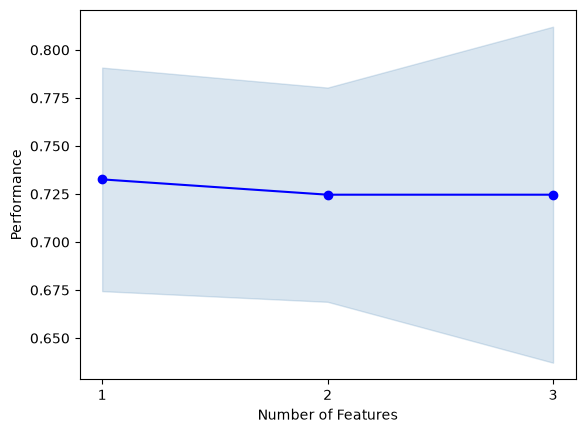

In [34]:
# Results
print("Selected features:", sfs.k_feature_names_)
print("Model accuracy:", sfs.k_score_)

# Plot accuracy progression
plot_sfs(sfs.get_metric_dict())
plt.show()

Sequential backward selection is another wrapper 
method
Preview: Docs Loading link description
 for feature selection. It is very similar to sequential forward selection, but there is one key difference. Instead of starting with no features and adding one feature at a time, sequential backward selection starts with all of the available features and removes one feature at a time.

In [35]:
# Sequential Backward Selection (3 features, 5-fold CV)
sbs = SFS(lr,
          k_features=3,
          forward=False,
          floating=False,
          scoring='accuracy',
          cv=5)
sbs.fit(X, y)

,estimator,LogisticRegre...max_iter=1000)
,k_features,"(3, ...)"
,forward,False
,scoring,'accuracy'
,floating,False
,verbose,0
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


Selected features: ('Glucose', 'Insulin', 'Leptin')
Model accuracy: 0.7242753623188406


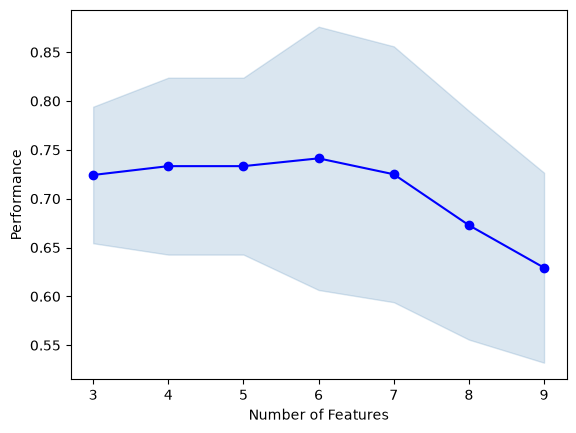

In [36]:
# Results
print("Selected features:", sbs.k_feature_names_)
print("Model accuracy:", sbs.k_score_)

# Plot accuracy progression
plot_sfs(sbs.get_metric_dict())
plt.show()

Sequential forward floating selection is a variation of sequential forward selection. It starts with zero features and adds one feature at a time, just like sequential forward selection, but after each addition, it checks to see if we can improve performance by removing a feature.

If performance can’t be improved, the floating 
algorithm
Preview: Docs An algorithm is a formal process used to solve a problem. They can be represented in several formats but are usually represented in pseudocode in order to communicate the process by which the algorithms solve the problems they were created to tackle.
 will continue to the next step and add another feature.
If performance can be improved, the algorithm will make the removal that improves performance the most (unless removal of that feature would lead to an infinite loop of adding and removing the same feature over and over again)

In [37]:
# Sequential Forward Floating Selection (3 features, 5-fold CV)
sffs = SFS(lr,
           k_features=3,
           forward=True,
           floating=True,
           scoring='accuracy',
           cv=5)
sffs.fit(X, y)
print("SFFS selected features:", sffs.k_feature_names_)
print("SFFS accuracy:", sffs.k_score_)

SFFS selected features: ('Glucose', 'HOMA', 'Leptin')
SFFS accuracy: 0.7246376811594203


Sequential backward floating selection works similarly. Starting with all available features, it removes one feature at a time. After each feature removal, it will check to see if any feature additions will improve performance (but it won’t add any features that would result in an infinite loop).

Floating selection algorithms are sometimes preferable to their non-floating counterparts because they test the model on more possible feature subsets. They can detect useful relationships between 
variables
Preview: Docs Loading link description
 that plain sequential forward and backward selection might miss.

In [38]:
# Sequential Backward Floating Selection (3 features, 5-fold CV)
sbfs = SFS(lr,
           k_features=3,
           forward=False,
           floating=True,
           scoring='accuracy',
           cv=5)
sbfs.fit(X, y)
print("SBFS selected features:", sbfs.k_feature_names_)
print("SBFS accuracy:", sbfs.k_score_)

SBFS selected features: ('Glucose', 'Insulin', 'Leptin')
SBFS accuracy: 0.7242753623188406


Recursive feature elimination is another wrapper method for feature selection. It starts by training a model with all available features. It then ranks each feature according to an importance metric and removes the least important feature. The algorithm then trains the model on the smaller feature set, ranks those features, and removes the least important one. The process stops when the desired number of features is reached.
It’s important to note that you might need to standardize data before doing recursive feature elimination. In regression problems in particular, it’s necessary to standardize data so that the scale of features doesn’t affect the size of the coefficients.

In [39]:
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler

feature_list = list(X.columns)
# Standardize predictors
X = StandardScaler().fit_transform(X)

# Logistic regression model
lr = LogisticRegression(max_iter=1000)

# Recursive Feature Elimination (select 3 features)
rfe = RFE(estimator=lr, n_features_to_select=3)
rfe.fit(X, y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",3
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[int64](2,)","[1,2]"
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,LogisticRegression,LogisticRegre...max_iter=1000)
n_features_ n_features_: intThe number of selected features.,int64,np.int64(3)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,9
"ranking_ ranking_: ndarray of shape (n_features,)The feature ranking, such that ``ranking_[i]`` corresponds to theranking position of the i-th feature. Selected (i.e., estimatedbest) features are assigned rank 1.","ndarray[int64](9,)","[4,1,1,...,7,1,6]"


In [40]:
# Selected features
rfe_features = [f for f, support in zip(feature_list, rfe.support_) if support]
print("Selected features:", rfe_features)

# Model accuracy with selected features
print("Model accuracy:", rfe.score(X, y))

Selected features: ['BMI', 'Glucose', 'Resistin']
Model accuracy: 0.7327586206896551
